In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
torch.manual_seed(42)
x=torch.randn(100,1)*10
y_true=2*x+3+torch.randn(100,1)*3
model=nn.Linear(1,1)
criterion=nn.MSELoss()
optimizer=optim.SGD(model.parameters(),lr=0.01)
print(f"初始 w:  {model.weight.item():.4f},初始b: {model.bias.item():.4f}")

初始 w:  0.4801,初始b: 0.8415


In [11]:
loss_history = []
epochs=100
for epoch in range(epochs):
    y_pred=model(x)
    loss=criterion(y_pred,y_true)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch[{epoch+1}/{epochs}],Loss:{loss.item():.4f},"
         f"w: {model.weight.item():.4f},b: {model.bias.item():.4f}")
print(f" \n训练结束，最终w: {model.weight.item():.4f},最终b: {model.bias.item():.4f}")

Epoch[1/100],Loss:240.6553,w: 3.4528,b: 0.9050
Epoch[2/100],Loss:211.1164,w: 0.6769,b: 0.9317
Epoch[3/100],Loss:185.3516,w: 3.2680,b: 0.9911
Epoch[4/100],Loss:162.8768,w: 0.8484,b: 1.0183
Epoch[5/100],Loss:143.2706,w: 3.1069,b: 1.0739
Epoch[6/100],Loss:126.1654,w: 0.9978,b: 1.1014
Epoch[7/100],Loss:111.2407,w: 2.9664,b: 1.1535
Epoch[8/100],Loss:98.2172,w: 1.1280,b: 1.1811
Epoch[9/100],Loss:86.8514,w: 2.8439,b: 1.2300
Epoch[10/100],Loss:76.9311,w: 1.2415,b: 1.2575
Epoch[11/100],Loss:68.2714,w: 2.7371,b: 1.3036
Epoch[12/100],Loss:60.7109,w: 1.3403,b: 1.3309
Epoch[13/100],Loss:54.1089,w: 2.6439,b: 1.3744
Epoch[14/100],Loss:48.3429,w: 1.4264,b: 1.4014
Epoch[15/100],Loss:43.3062,w: 2.5627,b: 1.4424
Epoch[16/100],Loss:38.9054,w: 1.5015,b: 1.4690
Epoch[17/100],Loss:35.0594,w: 2.4918,b: 1.5078
Epoch[18/100],Loss:31.6974,w: 1.5668,b: 1.5339
Epoch[19/100],Loss:28.7575,w: 2.4300,b: 1.5706
Epoch[20/100],Loss:26.1861,w: 1.6238,b: 1.5962
Epoch[21/100],Loss:23.9361,w: 2.3761,b: 1.6310
Epoch[22/100],L

正在使用设备: cuda
初始 w: 0.4801, 初始 b: 0.8415

训练结束，最终 w: 2.0035, 最终 b: 3.1070


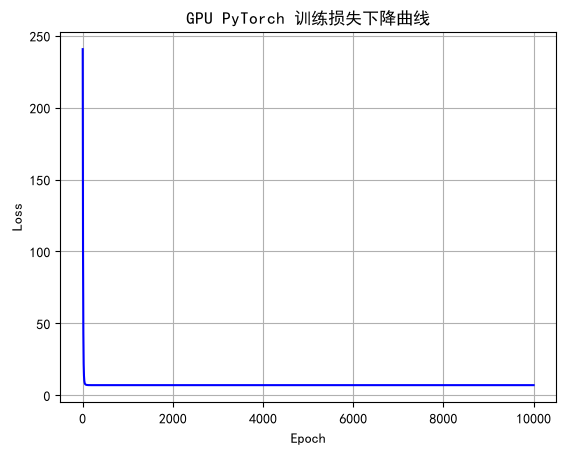

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#  设置设备（自动检测 GPU）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"正在使用设备: {device}")

torch.manual_seed(42)

#  造数据，并搬到 GPU
X = torch.randn(100, 1).to(device) * 10
y_true = (2 * X + 3 + torch.randn(100, 1).to(device) * 3)

#  定义模型，并搬到 GPU
model = nn.Linear(1, 1).to(device)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

print(f"初始 w: {model.weight.item():.4f}, 初始 b: {model.bias.item():.4f}")

#  训练循环
loss_history = []
epochs = 10000

for epoch in range(epochs):
    y_pred = model(X)
    loss = criterion(y_pred, y_true)
    loss_history.append(loss.item())
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"\n训练结束，最终 w: {model.weight.item():.4f}, 最终 b: {model.bias.item():.4f}")

#  画图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.plot(range(1, epochs+1), loss_history, color='blue')
plt.title("GPU PyTorch 训练损失下降曲线")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()